# NEW

In [5]:

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Tuple
from matplotlib.ticker import ScalarFormatter



In [13]:
def load_tracking_results(json_path: str) -> Dict:
    """Load tracking results from JSON file."""
    json_path = Path(json_path)
    if not json_path.exists():
        raise FileNotFoundError(f"No results file found at {json_path}")
    
    with open(json_path, 'r') as f:
        all_results = json.load(f)
    
    print(f"Loaded {len(all_results)} tracking scenarios")
    return all_results


def parse_scenario_name(scenario: str) -> Tuple[int, int]:
    """Parse scenario name to extract number of layers and tracks."""
    parts = scenario.replace('[', '').replace(']', '').split('_')
    n_layers = int(parts[0].replace('L', ''))
    n_tracks = int(parts[1].replace('T', ''))
    return n_layers, n_tracks


def calculate_matrix_size(n_layers: int, n_tracks: int) -> int:
    """Calculate the matrix size N from number of layers and tracks."""
    return (n_layers - 1) * n_tracks**2


def calculate_hellinger_fidelity(dist1: np.ndarray, dist2: np.ndarray) -> float:
    """Calculate Hellinger fidelity between two probability distributions."""
    return np.sum(np.sqrt(dist1 * dist2)) ** 2


def identify_track_bins(scenario_data: Dict,
                        baseline_emulator: str = 'H2-1LE',
                        circuit_type: str = '1BIT_2bin_2level',
                        threshold: float = 1e-10) -> np.ndarray:
    """Identify which bins correspond to valid tracks using the noiseless baseline."""
    baseline_mean = np.array(
        scenario_data[baseline_emulator][circuit_type]['normalized_vectors']['mean']
    )
    track_mask = baseline_mean > threshold
    return track_mask


def calculate_signal_separation_index(measured_dist: np.ndarray, track_mask: np.ndarray) -> float:
    """Calculate Signal Separation Index (SSI)."""
    track_probs = measured_dist[track_mask]
    noise_probs = measured_dist[~track_mask]
    
    if len(track_probs) == 0 or len(noise_probs) == 0:
        return np.nan
    
    mean_track = np.mean(track_probs)
    
    # Take top M noise bins, where M = number of track bins
    n_track_bins = len(track_probs)
    n_top_noise = min(n_track_bins, len(noise_probs))
    top_noise_probs = np.sort(noise_probs)[-n_top_noise:]
    mean_noise = np.mean(top_noise_probs)
    
    if mean_noise < 1e-15:
        return np.inf if mean_track > 1e-15 else 1.0
    
    return mean_track / mean_noise 

def compute_hellinger_with_errors(tracking_results: Dict,
                                   baseline_emulator: str = 'H2-1LE',
                                   circuit_type: str = '1BIT_2bin_2level',
                                   n_bootstrap: int = 1000, effective_shots: int = 10000) -> Dict:
    """Compute Hellinger fidelity vs baseline with error estimation."""
    results = {}
    
    for scenario, scenario_data in tracking_results.items():
        results[scenario] = {}
        
        try:
            baseline_mean = np.array(
                scenario_data[baseline_emulator][circuit_type]['normalized_vectors']['mean']
            )
        except (ValueError, KeyError) as e:
            print(f"Warning: Could not extract baseline for scenario '{scenario}': {e}")
            continue

        baseline_alphas = (baseline_mean + 1e-5) * effective_shots
        
        for emulator in scenario_data.keys():
            if emulator == baseline_emulator:
                continue
            if emulator == 'H2-2':
                effective_shots = 500
            elif emulator == 'H2-2' and scenario.startswith('5L_[4]T'):
                effective_shots = 800
            
            try:
                emulator_mean = np.array(
                    scenario_data[emulator][circuit_type]['normalized_vectors']['mean']
                )
                
                # Dirichlet alphas for this specific emulator
                emulator_alphas = (emulator_mean + 1e-5) * effective_shots

                metric_samples = []
                
                for _ in range(n_bootstrap):
                    # Sample both distributions from Dirichlet distributions
                    baseline_sample = np.random.dirichlet(baseline_alphas)
                    emulator_sample = np.random.dirichlet(emulator_alphas)
                    
                    metric_value = calculate_hellinger_fidelity(baseline_sample, emulator_sample)
                    metric_samples.append(metric_value)
                
                results[scenario][emulator] = {
                    'mean': np.mean(metric_samples),
                    'std': np.std(metric_samples)
                }
                
            except (KeyError, TypeError) as e:
                print(f"Warning: Could not process emulator '{emulator}' in scenario '{scenario}': {e}")
                continue
    
    return results

def compute_ssi_with_errors(tracking_results: Dict,
                            baseline_emulator: str = 'H2-1LE',
                            circuit_type: str = '1BIT_2bin_2level',
                            n_bootstrap: int = 1000, effective_shots: int = 10000) -> Dict:
    """Compute SSI with error estimation."""
    results = {}
    
    for scenario, scenario_data in tracking_results.items():
        results[scenario] = {}
        
        try:
            track_mask = identify_track_bins(scenario_data, baseline_emulator, circuit_type)
        except (ValueError, KeyError) as e:
            print(f"Warning: Could not identify track bins for scenario '{scenario}': {e}")
            continue
        
        for emulator in scenario_data.keys():
            if emulator == baseline_emulator:
                continue
            if emulator == 'H2-2' and scenario.startswith('5L_[4]T'):
                effective_shots = 800
            elif emulator == 'H2-2':
                effective_shots = 500

            try:
                emulator_mean = np.array(
                    scenario_data[emulator][circuit_type]['normalized_vectors']['mean']
                )

                ssi_samples = []
                
                alphas = (emulator_mean + 1e-5) * effective_shots
                
                for _ in range(n_bootstrap):
                    # Dirichlet natively outputs valid probability distributions (sum=1, p > 0)
                    emulator_sample = np.random.dirichlet(alphas)
                    
                    ssi = calculate_signal_separation_index(emulator_sample, track_mask)
                    
                    if not np.isinf(ssi) and not np.isnan(ssi):
                        ssi_samples.append(ssi)
                
                results[scenario][emulator] = {
                    'mean': np.mean(ssi_samples) if ssi_samples else np.nan,
                    'std': np.std(ssi_samples) if ssi_samples else np.nan
                }
                
            except (KeyError, TypeError) as e:
                print(f"Warning: Could not process emulator '{emulator}' in scenario '{scenario}': {e}")
                continue
    
    return results

def calculate_signal_separation_index_individual(measured_dist: np.ndarray, track_mask: np.ndarray, n_shots: int) -> float:
    """Calculate Signal Separation Index (SSI) for a single run with an empirical noise floor based on shots."""
    track_probs = measured_dist[track_mask]
    noise_probs = measured_dist[~track_mask]
    
    if len(track_probs) == 0 or len(noise_probs) == 0:
        return np.nan
    
    mean_track = np.mean(track_probs)
    
    # Take top M noise bins
    n_track_bins = len(track_probs)
    n_top_noise = min(n_track_bins, len(noise_probs))
    top_noise_probs = np.sort(noise_probs)[-n_top_noise:]
    mean_noise = np.mean(top_noise_probs)
    
    # Noise floor rule: Minimum detectable frequency is 1 / n_shots
    # This prevents Division by Zero for raw experimental hits.
    epsilon = 1.0 / n_shots
    
    return mean_track / (mean_noise + epsilon)


def compute_hellinger_with_errors_individual(tracking_results: Dict,
                                             baseline_emulator: str = 'H2-1LE',
                                             circuit_type: str = '1BIT_2bin_2level') -> Dict:
    """Compute Hellinger fidelity vs baseline by calculating over individual physical runs."""
    results = {}
    
    for scenario, scenario_data in tracking_results.items():
        results[scenario] = {}
        
        try:
            baseline_mean = np.array(
                scenario_data[baseline_emulator][circuit_type]['normalized_vectors']['mean']
            )
        except (ValueError, KeyError) as e:
            print(f"Warning: Could not extract baseline for scenario '{scenario}': {e}")
            continue

        for emulator in scenario_data.keys():
            if emulator == baseline_emulator:
                continue
            
            try:
                # Requires a list of numpy arrays, one for each raw physical execution
                raw_run_vectors = scenario_data[emulator][circuit_type]['normalized_vectors'].get('individual_runs', [])
                
                if not raw_run_vectors:
                    #print(f"Warning: Could not find raw individual run data for '{emulator}' in scenario '{scenario}'.")
                    continue
                
                metric_samples = []
                for raw_single_run in raw_run_vectors:
                    single_run_dist = np.array(raw_single_run)
                    
                    metric_value = calculate_hellinger_fidelity(baseline_mean, single_run_dist)
                    metric_samples.append(metric_value)
                
                results[scenario][emulator] = {
                    'mean': np.mean(metric_samples),
                    'std': np.std(metric_samples)
                }
                
            except (KeyError, TypeError) as e:
                print(f"Warning: Could not process emulator '{emulator}' in scenario '{scenario}': {e}")
                continue
    
    return results


def compute_ssi_with_errors_individual(tracking_results: Dict,
                                       baseline_emulator: str = 'H2-1LE',
                                       circuit_type: str = '1BIT_2bin_2level') -> Dict:
    """Compute SSI with error estimation calculated independently over raw physical runs."""
    results = {}
    
    for scenario, scenario_data in tracking_results.items():
        results[scenario] = {}
        
        try:
            track_mask = identify_track_bins(scenario_data, baseline_emulator, circuit_type)
        except (ValueError, KeyError) as e:
            print(f"Warning: Could not identify track bins for scenario '{scenario}': {e}")
            continue
        
        for emulator in scenario_data.keys():
            if emulator == baseline_emulator:
                continue
            
            # Determine shot count for epsilon smoothing
            n_shots = 10000
            if emulator == 'H2-2':
                if scenario.startswith('5L_[4]T'):
                    n_shots = 800
                else:
                    n_shots = 500

            try:
                # Requires a list of numpy arrays, one for each raw physical execution
                raw_run_vectors = scenario_data[emulator][circuit_type]['normalized_vectors'].get('individual_runs', [])
                
                if not raw_run_vectors:
                    #print(f"Warning: Could not find raw individual run data for '{emulator}' in scenario '{scenario}'.")
                    continue

                ssi_samples = []
                
                for raw_single_run in raw_run_vectors:
                    single_run_dist = np.array(raw_single_run)
                    
                    ssi = calculate_signal_separation_index_individual(single_run_dist, track_mask, n_shots)
                    
                    if not np.isinf(ssi) and not np.isnan(ssi):
                        ssi_samples.append(ssi)
                
                results[scenario][emulator] = {
                    'mean': np.mean(ssi_samples) if ssi_samples else np.nan,
                    'std': np.std(ssi_samples) if ssi_samples else np.nan
                }
                
            except (KeyError, TypeError) as e:
                print(f"Warning: Could not process emulator '{emulator}' in scenario '{scenario}': {e}")
                continue
    
    return results

In [15]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import ScalarFormatter
import numpy as np
from pathlib import Path

# ============================================================================
# 1. LOAD & COMPUTE METRICS
# ============================================================================

# Define path to tracking results
json_filepath = Path.cwd() / ".." / "data" / "Figure6" / "tracking_results.json"
print("Loading tracking results from:", json_filepath)
tracking_results = load_tracking_results(json_filepath)

hellinger_boot = compute_hellinger_with_errors(tracking_results, n_bootstrap=1000)
ssi_boot = compute_ssi_with_errors(tracking_results, n_bootstrap=1000)

hellinger_indv = compute_hellinger_with_errors_individual(tracking_results)
ssi_indv = compute_ssi_with_errors_individual(tracking_results)

# Prepare scenarios for X-axis layout
scenarios = sorted(hellinger_boot.keys(), key=lambda s: (
    parse_scenario_name(s)[1], parse_scenario_name(s)[0]
))

x_positions, x_tick_labels = [], []
for scenario in scenarios:
    n_layers, n_tracks = parse_scenario_name(scenario)
    x_positions.append(calculate_matrix_size(n_layers, n_tracks))
    x_tick_labels.append(f"{n_tracks}T\n{n_layers}L")


Loading tracking results from: /Users/xenofonchiotopoulos/Desktop/PHD_STUFF/OneBQF/plotting_notebooks/../data/Figure6/tracking_results.json
Loaded 5 tracking scenarios


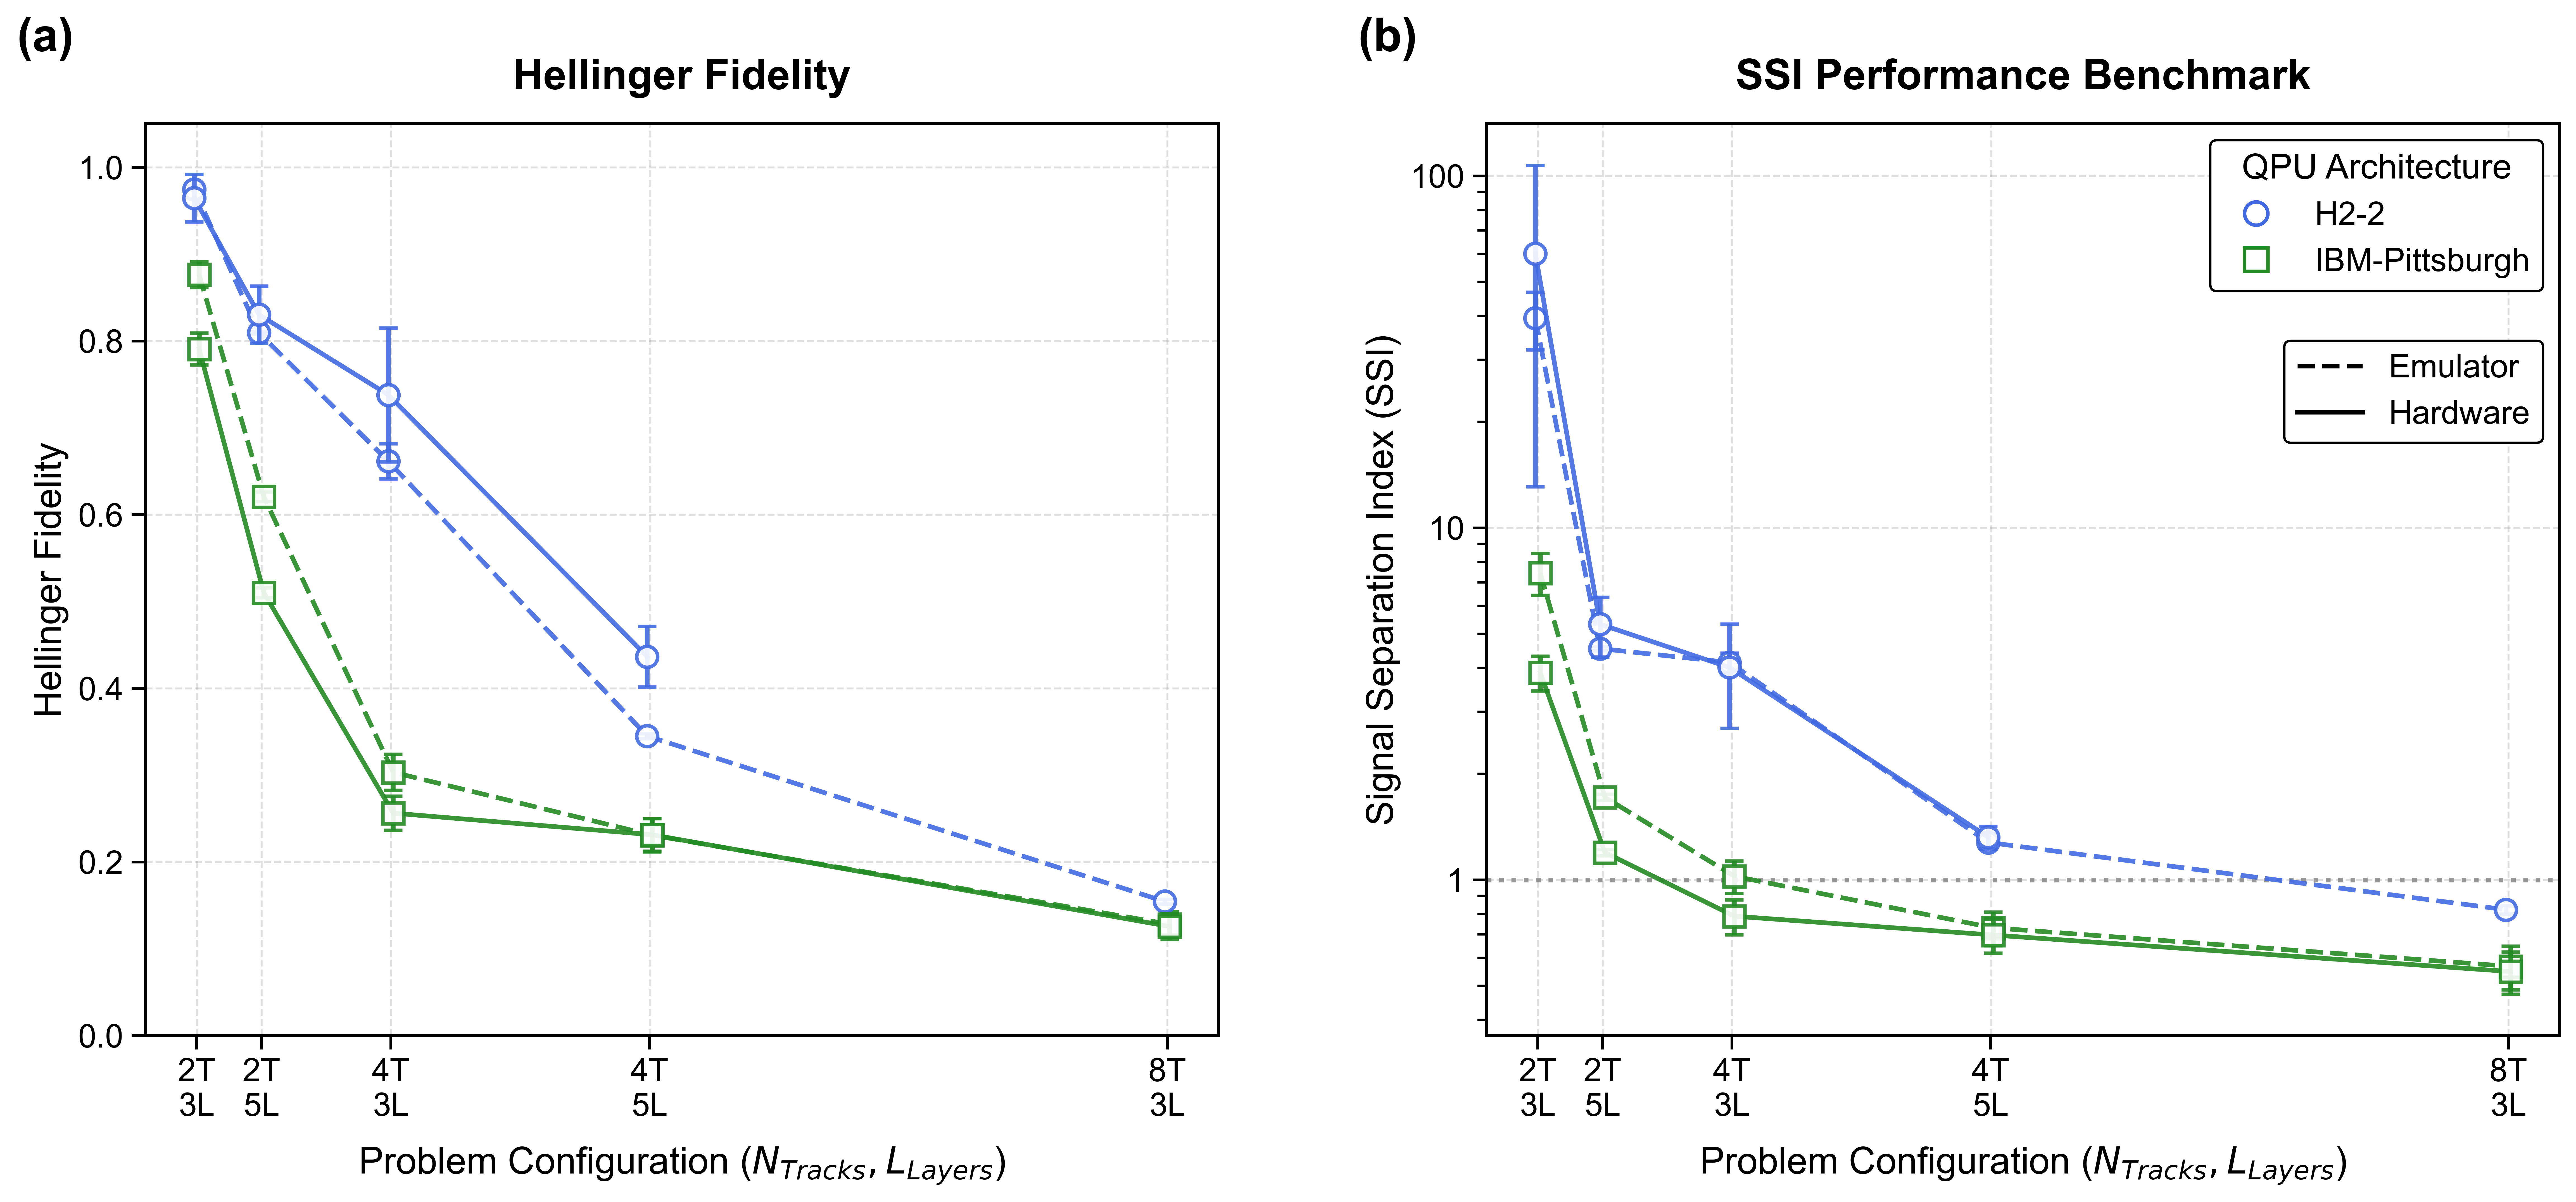

In [16]:
# ============================================================================
# NEW CELL: HYBRID PUBLICATION PLOT (Optimized for Black & White Printing)
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from matplotlib.ticker import ScalarFormatter
from pathlib import Path

# Provide explicit list of emulators we are analyzing
hybrid_emulators = ['H2-2', 'H2-2E', 'Qiskit-Pittsburgh-Hardware-EM', 'Qiskit-Pittsburgh']

# B&W AND Color Friendly mappings (using shapes, fill styles, and line styles alongside distinct colors)
styles_mapping = {
    'H2-2': {'marker': 'o', 'color': 'royalblue', 'facecolor': 'white', 'edgecolor': 'royalblue'},     # Hollow Blue Circle
    'Qiskit-Pittsburgh': {'marker': 's', 'color': 'forestgreen', 'facecolor': 'white', 'edgecolor': 'forestgreen'}, # Hollow Green Square
}

def get_base_name(name):
    base = name.replace('-Hardware-EM', '').replace('-Hardware', '')
    if base in ['H2-2E', 'H2-Emulator']:
        return 'H2-2'
    return base

# Create Figure
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

fig = plt.figure(figsize=(16, 8), dpi=600)
gs = fig.add_gridspec(1, 2, hspace=0.05, wspace=0.25,
                      left=0.08, right=0.98, top=0.90, bottom=0.22)

handles, labels = [], []

# Panels
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# Data configuration tuples mapping axes, title, ylabel, dictionary for Indv, and dictionary for Boot
plot_configs = [
    (ax1, 'Hellinger Fidelity', 'Hellinger Fidelity', hellinger_indv, hellinger_boot),
    (ax2, 'Signal Separation Index (SSI)', 'SSI Performance Benchmark', ssi_indv, ssi_boot)
]

for i, (ax, ylabel, title, indv_dict, boot_dict) in enumerate(plot_configs):
    
    for emulator in hybrid_emulators: 
        
        base_name = get_base_name(emulator)
        style_vars = styles_mapping.get(base_name)
        
        # --- B&W FRIENDLY LINE MAPPING ---
        if 'Hardware-EM' in emulator or emulator == 'H2-2':
            linestyle, label_suffix = '-', ' (Hardware EM)'
            zorder = 3
        else:
            linestyle, label_suffix = '--', ' (Emulator)'
            zorder = 2
            
        # =========================================================
        # TARGET DATA ROUTING:
        # =========================================================
        if emulator in ['Qiskit-Pittsburgh', 'Qiskit-Pittsburgh-Hardware-EM']:
            res_dict = boot_dict
        elif emulator in ['H2-2', 'H2-2E']:
            res_dict = indv_dict
        else:
            continue
        
        means, stds = [], []
        
        for scenario in scenarios:
            res = res_dict[scenario].get(emulator, {'mean': np.nan, 'std': 0})
            means.append(res['mean'])
            stds.append(res['std'])
            
        # Slight x-shift to avoid exact overlaps of error bars in B&W
        shift = -0.3 if base_name == 'H2-2' else 0.3
        x_shifted = [x + shift for x in x_positions]
        
        # Plotting with strong contrast elements
        ax.errorbar(x_shifted, means, yerr=stds,
                    marker=style_vars['marker'], linewidth=2.0, linestyle=linestyle, 
                    markersize=9, capsize=4, capthick=1.5,
                    color=style_vars['color'], alpha=0.9, 
                    markerfacecolor=style_vars['facecolor'], 
                    markeredgecolor=style_vars['edgecolor'], 
                    markeredgewidth=1.5, zorder=zorder)
        
        # Collect legend handles only once per QPU base architecture
        if i == 0:
            full_label = base_name.replace('Qiskit', 'IBM')
            if full_label not in labels:
                proxy = mlines.Line2D([], [], color=style_vars['color'], marker=style_vars['marker'], linestyle='none', 
                                       linewidth=1.8, markersize=10, 
                                       markerfacecolor=style_vars['facecolor'],
                                       markeredgecolor=style_vars['edgecolor'], 
                                       markeredgewidth=1.5)
                handles.append(proxy)
                labels.append(full_label)

    # General Axes Formatting
    ax.set_xlabel('Problem Configuration ($N_{Tracks}, L_{Layers}$)', fontsize=16, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_tick_labels, fontsize=14)
    
    # Tick parameters for publication readability
    ax.tick_params(axis='both', which='major', labelsize=14, length=6, width=1.2)
    ax.tick_params(axis='both', which='minor', length=4, width=1.0)
    ax.grid(True, alpha=0.25, color='gray', linestyle='--', linewidth=0.8)
    
    if i == 0:
        ax.set_ylim(0, 1.05)
        ax.text(-0.12, 1.08, '(a)', transform=ax.transAxes, fontsize=20, fontweight='bold')
    else:
        ax.set_yscale('log')
        ax.axhline(y=1, color='gray', linestyle=':', linewidth=2.0, alpha=0.8)
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.text(-0.12, 1.08, '(b)', transform=ax.transAxes, fontsize=20, fontweight='bold')

# --- Main Hardware Shape Legend ---
legend_qpu = ax2.legend(handles, labels, loc='upper right', 
            ncol=1, fontsize=14, 
            title='QPU Architecture', title_fontsize=15, frameon=True, edgecolor='black', framealpha=1.0)

# --- Secondary Line Style Legend ---
style_lines = [
    mlines.Line2D([], [], color='black', linestyle='--', linewidth=2.0),
    mlines.Line2D([], [], color='black', linestyle='-', linewidth=2.0)
]
style_labels = ['Emulator', 'Hardware']

legend_style = ax2.legend(style_lines, style_labels, 
            loc='upper right', bbox_to_anchor=(1.0, 0.78), ncol=1, fontsize=14, 
            frameon=True, edgecolor='black', framealpha=1.0)

ax2.add_artist(legend_qpu)

# Save with a high DPI format specifically targeting print formatting
#plt.savefig("publication_bw_trackhhl.pdf", format='pdf', dpi=600, bbox_inches='tight')
#plt.savefig("publication_bw_trackhhl.png", format='png', dpi=600, bbox_inches='tight')
plt.show()